<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-04-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 04
### Supervised Learning - Regression and Classification Algorithms

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026 – 2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | **125M1H026** |
| **Student Name** | **Shantanu Suryawanshi** |
| **Submission Date** | **04-09-2026** |
</div>

---
## Instructions to Students

- Fill in your **PRN**, **Name**, **Class/Division**, and **Submission Date** in the header table above.
- Write all Python code in the code cells provided below each step of each question.
- Execute each code cell and ensure there are **no errors** before submission.
- Do **not** modify the question cells.
- Submit the completed `.ipynb` file on the Google Classroom portal by the due date.

---

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    mean_squared_error, 
    r2_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

plt.rcParams['figure.figsize'] = (12, 9)

# 1) Supervised Learning - Regression Algorithms [CO4]

### Objectives & Steps:
- **Data Preprocessing:**
  - Load the dataset and inspect the first few rows.
  - Handle missing values if necessary.
  - Perform feature scaling/normalization on numerical features.
- **Train/Test Split:**
  - Split the data into training and testing sets (80% training, 20% testing).
- **Linear Regression Model:**
  - Implement linear regression using scikit-learn.
  - Train the model on the training data.
  - Make predictions on the test set.
- **Model Evaluation:**
  - Use metrics like Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared to evaluate the model.

---
## Question 1 (a): Linear Regression on California Housing Dataset
**Question:** Implement a linear regression model to predict house prices based on various features: Use the "California Housing" dataset (or similar) which contains features like `median_income`, `housing_median_age`, `total_rooms`, etc.
- **URL:** [California Housing Prices Dataset](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

#### Step 1: Load the California Housing dataset and inspect the first few rows

In [3]:

df = pd.read_csv('./housing.csv')

print("Dataset")
print(df.head())


Dataset
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [4]:
print("Shape:", df.shape)

Shape: (20640, 10)


In [5]:
print("Information:")
df.info()

Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


#### Step 2: Check for missing values in the dataset

In [6]:

print(" Missing Count ")
missing_vals = df.isnull().sum()
print(missing_vals)

# Handle missing values if any exist
if missing_vals.sum() > 0:
    df = df.dropna()
    print(" deliting Missing values rows.")


 Missing Count 
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
 deliting Missing values rows.


In [9]:
print("After deleting Missing values rows Shape:", df.shape)

After deleting Missing values rows Shape: (20433, 10)


In [13]:
df['ocean_proximity'] = df['ocean_proximity'].astype('category')
df['ocean_proximity'] = df['ocean_proximity'].cat.codes

In [ ]:
print("After encoding 'ocean_proximity' column:")
print(df.head(10))

#### Step 3: Define independent features (X) and target variable (y), and perform feature scaling

In [14]:

# Target variable is MedHouseVal
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

print("Features (X):", list(X.columns))
print("Target (y): median_house_value")


Features (X): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
Target (y): median_house_value


In [15]:
# Applying feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Features :")
print(X_scaled[:10])

Scaled Features :
[[-1.32731375  1.05171726  0.98216331 -0.8038126  -0.97032521 -0.97331952
  -0.97683327  2.34516291  1.29135065]
 [-1.32232256  1.04235526 -0.60621017  2.0421302   1.34827594  0.86133924
   1.67037262  2.33263161  1.29135065]
 [-1.33230494  1.03767426  1.85576873 -0.53518928 -0.82556097 -0.81976943
  -0.84342665  1.78293943  1.29135065]
 [-1.33729614  1.03767426  1.85576873 -0.62351007 -0.71876767 -0.76505618
  -0.73356237  0.93297     1.29135065]
 [-1.33729614  1.03767426  1.85576873 -0.46196998 -0.61197437 -0.75887888
  -0.62892973 -0.01314291  1.29135065]
 [-1.33729614  1.03767426  1.85576873 -0.7859654  -0.77097772 -0.89301459
  -0.80157359  0.08721277  1.29135065]
 [-1.33729614  1.03299326  1.85576873 -0.04645043 -0.11597883 -0.29205133
   0.03810338 -0.11165575  1.29135065]
 [-1.33729614  1.03299326  1.85576873  0.21393571  0.35391168 -0.23645561
   0.38600692 -0.39550542  1.29135065]
 [-1.34228733  1.03299326  1.06158199 -0.03729802  0.30170162 -0.1932145
   0.

#### Step 4: Split data into training and testing sets (80% train, 20% test)

In [16]:
# Step 4: 80% Training and 20% Testing Split
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

print(f"Total Samples: {len(df)}")
print(f"Training Samples : {X_train_cal.shape[0]}")
print(f"Testing Samples : {X_test_cal.shape[0]}")

Total Samples: 20433
Training Samples : 16346
Testing Samples : 4087


#### Step 5: Implement and train the Linear Regression model

In [17]:
# Step 5: Create and train Linear Regression model
model = LinearRegression()
model.fit(X_train_cal, y_train_cal)


print(" Intercept:", model.intercept_)
print(" Coefficients:", model.coef_)

 Intercept: 206617.47858224344
 Coefficients: [-85688.28469315 -90756.32194707  14565.80272066 -18298.20433088
  48862.96931622 -41787.91373246  15851.99637839  76462.73883097
   -559.65964712]


#### Step 6: Make predictions on the test set

In [18]:
# Step 6: Make predictions on test data
y_pred = model.predict(X_test_cal)

# Display sample predictions vs actual values
df_pred = pd.DataFrame({
    'Actual Value': y_test_cal.values[:5],
    'Predicted Value': y_pred[:5],
    'Difference': y_test_cal.values[:5] - y_pred[:5]
})

print(df_pred)

   Actual Value  Predicted Value    Difference
0      245800.0    195854.433791  49945.566209
1      137900.0    157564.349841 -19664.349841
2      218200.0    202476.830299  15723.169701
3      220800.0    173038.268113  47761.731887
4      170500.0    214022.310405 -43522.310405


#### Step 7: Model Evaluation (MSE, RMSE, and R-squared)

In [22]:
# Step 7: Evaluate the model performance
mse_cal = mean_squared_error(y_test_cal, y_pred)
rmse_cal = np.sqrt(mse_cal)
r2_cal = r2_score(y_test_cal, y_pred)


print(f"Mean Squared Error (MSE)       : {mse_cal:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse_cal:.4f}")
print(f"R-squared (R2 Score)           : {r2_cal:.4f}")

Mean Squared Error (MSE)       : 4924108937.9120
Root Mean Squared Error (RMSE) : 70171.9954
R-squared (R2 Score)           : 0.6399


#### Step 8: Visualization - Actual vs Predicted House Prices

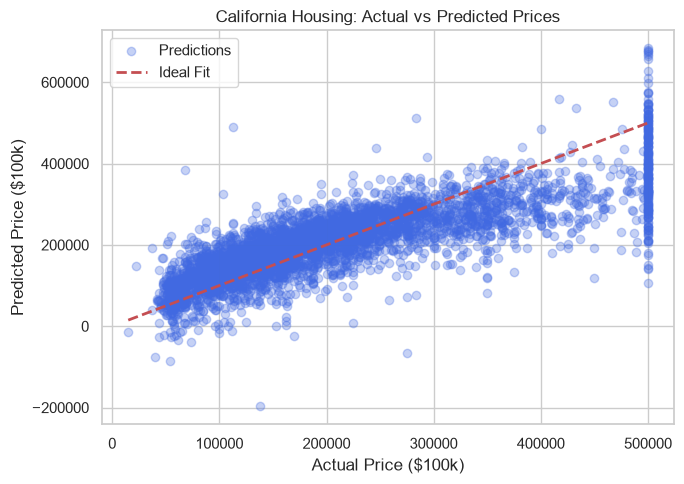

In [23]:
# Step 8: Scatter plot of Actual vs Predicted House Prices
plt.figure(figsize=(7, 5))
plt.scatter(y_test_cal, y_pred, color='royalblue', alpha=0.3, label='Predictions')
plt.plot([y_test_cal.min(), y_test_cal.max()], [y_test_cal.min(), y_test_cal.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.title('California Housing: Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.show()

---
## Question 1 (b): Linear Regression on Automobile Dataset
**Question:** Implement a linear regression model to predict car prices based on various features such as engine size, horsepower, curb weight, etc.: Use the "Automobile" dataset, which contains various features related to cars and their prices. You can get this dataset from the UCI Machine Learning Repository.
- **URL:** [Automobile Dataset](https://www.kaggle.com/datasets/toramky/automobile-dataset)

#### Step 1: Load the Automobile dataset and inspect the first few rows

In [ ]:
# Step 1: Load Automobile dataset
df = pd.read_csv('automobile.csv')

print("Dataset")
print(df.head())
print("Shape:", df.shape)

In [26]:
print( "coloums : " , df.columns.tolist() )

coloums :  ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


#### Step 2: Handle missing values and data cleaning

In [35]:
# Step 2: Check and clean missing values
print("Checking missing values :")
print(df[['price', 'horsepower', 'curb-weight', 'engine-type', 'city-mpg', 'highway-mpg']].isnull().sum())

# Drop rows where target variable 'price' is missing
df = df.dropna(subset=['price'])


Checking missing values :
price          0
horsepower     0
curb-weight    0
engine-type    0
city-mpg       0
highway-mpg    0
dtype: int64


In [36]:
# Fill missing numerical values with their median
for col in ['horsepower', 'bore', 'stroke', 'normalized_losses', 'peak_rpm']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

In [ ]:
print("Missing values after cleaning:")
print(df[['price', 'horsepower', 'curb-weight', 'engine-type', 'city-mpg', 'highway-mpg']].isnull().sum())
print("Cleaned Dataset Shape:", df.shape)

#### Step 3: Select numerical features and perform feature scaling

In [43]:
# Step 3: Select features and target
features = ['engine-type', 'horsepower', 'curb-weight', 'city-mpg', 'highway-mpg', 'wheel-base']
X = df[features]
print("Data Types:", X.dtypes)


Data Types: engine-type        str
horsepower     float64
curb-weight      int64
city-mpg         int64
highway-mpg      int64
wheel-base     float64
dtype: object


In [44]:
X['engine-type'] = X['engine-type'].astype('category').cat.codes
print("Data Types:", X.dtypes)
y = df['price']

Data Types: engine-type       int8
horsepower     float64
curb-weight      int64
city-mpg         int64
highway-mpg      int64
wheel-base     float64
dtype: object


In [45]:
print("Selected Features:", features)
print("Target Variable: price")

Selected Features: ['engine-type', 'horsepower', 'curb-weight', 'city-mpg', 'highway-mpg', 'wheel-base']
Target Variable: price


In [46]:
# Perform feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:2])

[[-2.86510549  0.17330945 -0.01456628 -0.64655303 -0.54605874 -1.6907718 ]
 [-2.86510549  0.17330945 -0.01456628 -0.64655303 -0.54605874 -1.6907718 ]]


#### Step 4: Split data into training (80%) and testing (20%) sets

In [47]:
# Step 4: 80% Training and 20% Testing Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

print(f"Total Cleaned Samples: {len(df)}")
print(f"Training Samples (80%): {X_train.shape[0]}")
print(f"Testing Samples (20%): {X_test.shape[0]}")

Total Cleaned Samples: 205
Training Samples (80%): 164
Testing Samples (20%): 41


#### Step 5: Implement and train the Linear Regression model

In [ ]:
# Step 5: Build and fit Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)


print(" Intercept:", model.intercept_)
for f, c in zip(features, model.coef_):
    print(f"Coefficient for {f}: {c:.2f}")

#### Step 6: Make predictions on the test set

In [ ]:
# Step 6: Predict prices on test data
y_pred = model.predict(X_test)

# Display sample predictions vs actual prices
df_pred = pd.DataFrame({
    'Actual Price': y_test.values[:5],
    'Predicted Price': y_pred[:5],
    'Difference': y_test.values[:5] - y_pred[:5]
})
print("=== Sample Predictions vs Actual Prices ===")
print(df_pred)

#### Step 7: Model Evaluation (MSE, RMSE, and R-squared)

In [ ]:
# Step 7: Evaluate regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Automobile Price Prediction - Model Evaluation ===")
print(f"Mean Squared Error (MSE)       : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
print(f"R-squared (R2 Score)           : {r2:.4f}")

#### Step 8: Visualization - Actual vs Predicted Car Prices

In [ ]:
# Step 8: Plot Actual vs Predicted Car Prices
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='darkorange', edgecolors='k', s=60, label='Predicted Points')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Automobile: Actual vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.show()

# 2) Supervised Learning - Classification Algorithms [CO4]

### Objectives & Steps:
- **Data Preprocessing:**
  - Load the dataset and inspect the first few rows.
  - Handle missing values if necessary.
  - Convert categorical features to numeric using one-hot encoding or label encoding.
- **Train/Test Split:**
  - Split the data into training and testing sets (80% training, 20% testing).
- **Classification Model:**
  - Implement logistic regression / decision tree using scikit-learn.
  - Train the model on the training data.
  - Make predictions on the test set.
- **Model Evaluation:**
  - Evaluate the model using metrics such as accuracy, precision, recall, and F1-score.

---
## Question 2 (a): Logistic Regression on Pima Indians Diabetes Dataset
**Question:** Implement a logistic regression model to predict whether a person has diabetes based on various health features: Use the "Pima Indians Diabetes" dataset, which contains features like `Pregnancies`, `Glucose`, `BloodPressure`, etc.
- **URL:** [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

#### Step 1: Load the Diabetes dataset and inspect the first few rows

In [ ]:
# Step 1: Load Pima Indians Diabetes dataset
df = pd.read_csv('diabetes.csv')


print(df.head())
print("Shape:", df.shape)
print("Target Class Distribution:")
print(df['Outcome'].value_counts())

#### Step 2: Inspect missing values and summary statistics

In [ ]:
# Step 2: Check for null/missing values
print("Missing Values")
print(df.isnull().sum())

print("Summary Statistics")
print(df.describe())

#### Step 3: Separate features (X) and target (y), and perform feature scaling

In [ ]:
# Step 3: Define features and target variable
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print("Features (X):", list(X.columns))
print("Target (y): Outcome (0 = No Diabetes, 1 = Diabetes)")

# Scale numerical features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 2 scaled rows:")
print(X_scaled[:2])

#### Step 4: Split data into training (80%) and testing (20%) sets

In [ ]:
# Step 4: 80% Training and 20% Testing Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

print(f"Total Samples: {len(df)}")
print(f"Training Samples (80%): {X_train.shape[0]}")
print(f"Testing Samples (20%): {X_test.shape[0]}")

#### Step 5: Implement and train the Logistic Regression model

In [ ]:
# Step 5: Build and train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print(" Coefficients:", model.coef_)
print(" Intercept:", model.intercept_)

#### Step 6: Make predictions on the test set

In [ ]:
# Step 6: Predict on test set
y_pred = model.predict(X_test)

# Display sample predictions vs actual outcomes
df_pred = pd.DataFrame({
    'Actual Outcome': y_test.values[:10],
    'Predicted Outcome': y_pred[:10]
})
print(" Predictions")
print(df_pred)

#### Step 7: Model Evaluation (Accuracy, Precision, Recall, F1-Score, and Confusion Matrix)

In [ ]:
# Step 7: Evaluate classification metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(" Model Evaluation")
print(f"Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

#### Step 8: Visualization - Confusion Matrix Heatmap

In [ ]:
# Step 8: Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diab (0)', 'Diab (1)'],
            yticklabels=['No Diab (0)', 'Diab (1)'])
plt.title('Diabetes Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

---
## Question 2 (b): Decision Tree Classifier on Titanic Dataset
**Question:** Build a decision tree classifier to predict whether a person survives or not based on Titanic dataset features: Use the "Titanic" dataset which contains features like `Pclass`, `Age`, `Sex`, etc.
- **URL:** [Titanic Dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)

#### Step 1: Load the Titanic dataset and inspect the first few rows

In [ ]:
# Step 1: Load Titanic dataset
df = pd.read_csv('titanic.csv')

print("Dataset ")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nSurvival Count:")
print(df['Survived'].value_counts())

#### Step 2: Handle missing values in the dataset

In [ ]:
# Step 2: Check and fill missing values
print("Missing Values Before ")
print(df.isnull().sum())

# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill missing Fare with median if any
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Drop Cabin as it has too many missing values
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

print(" Missing Values After Imputation")
print(df.isnull().sum())

#### Step 3: Convert categorical features to numeric using Label Encoding

In [ ]:
# Step 3: Encode categorical features (Sex and Embarked)
sex = LabelEncoder()
df['Sex'] = sex.fit_transform(df['Sex'])

embarked = LabelEncoder()
df['Embarked'] = embarked.fit_transform(df['Embarked'])

print("Encoded 'Sex' :", dict(zip(sex.classes_, sex.transform(sex.classes_))))
print("Encoded 'Embarked':", dict(zip(embarked.classes_, embarked.transform(embarked.classes_))))
print("\nDataset preview after encoding:")
print(df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']].head())

#### Step 4: Select features and split data into training (80%) and testing (20%) sets

In [ ]:
# Step 4: Define features and target variable
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

# 80% Training and 20% Testing Split
X_train_tit, X_test_tit, y_train_tit, y_test_tit = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Total Samples: {len(df)}")
print(f"Training Samples : {X_train_tit.shape[0]}")
print(f"Testing Samples : {X_test_tit.shape[0]}")

#### Step 5: Implement and train the Decision Tree Classifier

In [17]:
# Step 5: Build and train Decision Tree Classifier
# max_depth=3 is used for easy readability and preventing overfitting
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_model.fit(X_train_tit, y_train_tit)



,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

#### Step 6: Make predictions on the test set

In [19]:
# Step 6: Predict survival on test set
y_pred = dt_model.predict(X_test_tit)

# Display sample predictions vs actual survival
df_pred = pd.DataFrame({
    'Actual Survived': y_test_tit.values[:10],
    'Predicted Survived': y_pred[:10]
})
print("Predictions")
print(df_pred)

Predictions
   Actual Survived  Predicted Survived
0                1                   0
1                0                   0
2                0                   0
3                1                   1
4                1                   1
5                1                   1
6                1                   1
7                0                   0
8                1                   1
9                1                   1


#### Step 7: Model Evaluation (Accuracy, Precision, Recall, F1-Score, and Confusion Matrix)

In [21]:
# Step 7: Evaluate classification metrics
acc_tit = accuracy_score(y_test_tit, y_pred)
prec_tit = precision_score(y_test_tit, y_pred)
rec_tit = recall_score(y_test_tit, y_pred)
f1_tit = f1_score(y_test_tit, y_pred)

print(" Model Evaluation")
print(f"Accuracy  : {acc_tit:.4f} ({acc_tit*100:.2f}%)")
print(f"Precision : {prec_tit:.4f}")
print(f"Recall    : {rec_tit:.4f}")
print(f"F1-Score  : {f1_tit:.4f}")

print("Classification Report")
print(classification_report(y_test_tit, y_pred, target_names=['Did not survive', 'Survived']))

 Model Evaluation
Accuracy  : 0.7989 (79.89%)
Precision : 0.7969
Recall    : 0.6892
F1-Score  : 0.7391
Classification Report
                 precision    recall  f1-score   support

Did not survive       0.80      0.88      0.84       105
       Survived       0.80      0.69      0.74        74

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



#### Step 8: Visualization - Decision Tree Diagram and Confusion Matrix

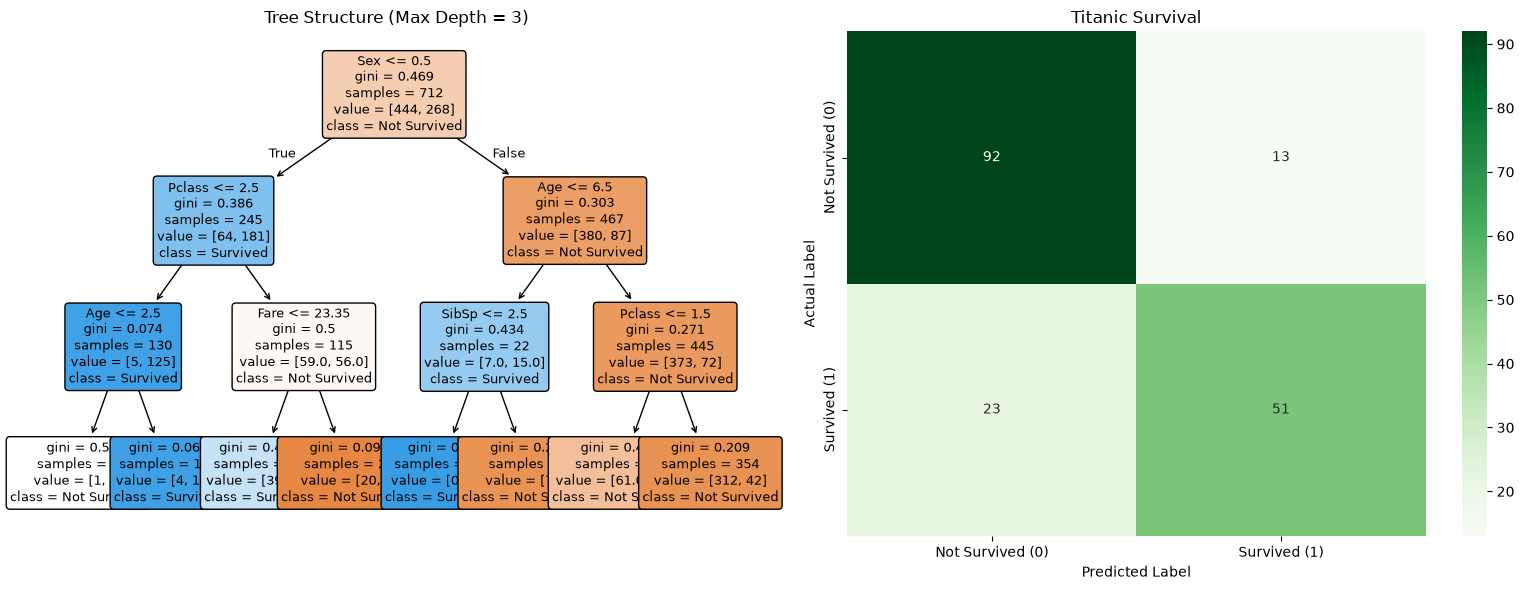

In [22]:
# Step 8: Visualizing the Decision Tree and Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Decision Tree Structure
plot_tree(dt_model, 
          feature_names=features, 
          class_names=['Not Survived', 'Survived'], 
          filled=True, 
          rounded=True, 
          fontsize=9,
          ax=axes[0])
axes[0].set_title(' Tree Structure (Max Depth = 3)')

# Subplot 2: Confusion Matrix Heatmap
cm_tit = confusion_matrix(y_test_tit, y_pred)
sns.heatmap(cm_tit, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Survived (0)', 'Survived (1)'],
            yticklabels=['Not Survived (0)', 'Survived (1)'],
            ax=axes[1])
axes[1].set_title('Titanic Survival')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual Label')

plt.tight_layout()
plt.show()

---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** |Shantanu Suryawanshi |
| **PRN** | 125M1H026|
| **Date** | 04-09-2026|

---

**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

![](https://img.shields.io/badge/MCA33PE21-Advanced%20Data%20Science%20Lab-blue?style=flat-square)
![](https://img.shields.io/badge/Practical%20Assignment-01-green?style=flat-square)

</div>